# Ablation Comparison: Pair vs Triplet STDP Across Spike Encodings

This notebook recreates all of Logan's spike encoding trials from `results.txt` and compares **pair-based STDP** (`TRIPLET_EN=0`) against **triplet STDP** (`TRIPLET_EN=1`) for each encoding.

Each encoding defines how WHITE (low-rate) and BLACK (high-rate) pixels are converted to 40-timestep spike trains. The SNN trains on 5x5 images of "0" and "1", then tests on slightly different variants.

In [10]:
import subprocess, re, os, numpy as np, matplotlib.pyplot as plt, pandas as pd
from collections import OrderedDict

REPO = os.path.expanduser("/mnt/c/Users/logan/OneDrive/Documents/year-5-winter/ece-274/hw4/test-other-code/triplet-snn")

# 7 encodings from Logan's results.txt
ENCODINGS = OrderedDict({
    "test4": {
        "name": "Uniform high-rate BLACK (bad)",
        "white": "1000000000100000000010000000001000000000",
        "black": "1111111111111111111111111111111111111111",
    },
    # "test5": {
    #     "name": "Alternating BLACK (bad)",
    #     "white": "1000000000100000000010000000001000000000",
    #     "black": "0101001010100101010010101001010100101010",
    # },
    # "test6": {
    #     "name": "Base case (works)",
    #     "white": "1000000000100000000010000000001000000000",
    #     "black": "1100110000001100110000001100110000001100",
    # },
    # "test7": {
    #     "name": "Sparser doublet BLACK (worse)",
    #     "white": "1000000000100000000010000000001000000000",
    #     "black": "1000100000001000100000001000100000001000",
    # },
    # "test8": {
    #     "name": "Silent WHITE (worse)",
    #     "white": "0000000000000000000000000000000000000000",
    #     "black": "1100110000001100110000001100110000001100",
    # },
    # "test9": {
    #     "name": "Triple-tap burst (triplet advantage)",
    #     "white": "0000100000000001000000000010000000000010",
    #     "black": "1110000011100000111000001110000011100000",
    # },
    # "test11": {
    #     "name": "Prime-and-Fire motif (triplet advantage)",
    #     "white": "0000010000000000001000000000000100000000",
    #     "black": "1011000000101100000010110000001011000000",
    # },
    # "test13": {
    #     "name": "High-Frequency Chatter (triplet advantage)",
    #     "white": "0000000100000000000010000000000000010000",
    #     "black": "1010100000101010000010101000001010100000",
    # },
})

print(f"Loaded {len(ENCODINGS)} encodings")

Loaded 1 encodings


In [12]:
def run_ablation(white, black, triplet_en):
    """Run one simulation using the original pair or triplet RTL files."""
    dflags = [
        "-DTEST_ONLY",
        f"-DSPIKE_WHITE=40'b{white}",
        f"-DSPIKE_BLACK=40'b{black}",
    ]

    if triplet_en:
        rtl_src = "rtl/triplet_snn.v"
        tb_src = "tb/triplet_snn_tb.v"
        out_name = "triplet_snn_ablation"
        w_bits = 4  # triplet_snn uses 4-bit weights
    else:
        rtl_src = "rtl/snn_network.v"
        tb_src = "tb/snn_network_tb.v"
        out_name = "pair_snn_ablation"
        w_bits = 2  # snn_network uses 2-bit weights

    # Compile
    compile_cmd = ["iverilog"] + dflags + ["-o", out_name, rtl_src, tb_src]
    subprocess.run(compile_cmd, cwd=REPO, capture_output=True, text=True, timeout=30, check=True)

    # Run
    run_cmd = ["vvp", out_name]
    result = subprocess.run(run_cmd, cwd=REPO, capture_output=True, text=True, timeout=60)
    stdout = result.stdout + result.stderr

    # Parse all weight snapshots: "BEFORE W1: 1 0 0 ..." or "AFTER W1: ..."
    weight_pattern = re.compile(r"(BEFORE|AFTER) (W[12]): ([\d ]+)")
    weights = {}
    for m in weight_pattern.finditer(stdout):
        label, wname, vals = m.group(1), m.group(2), m.group(3)
        arr = np.array([int(x) for x in vals.split()]).reshape(5, 5)
        key = f"{label}_{wname}"
        if key not in weights:
            weights[key] = []
        weights[key].append(arr)

    # Parse firing counts per phase
    firing_pattern = re.compile(r"Firing counts: Neuron 1 = (\d+), Neuron 2 = (\d+)")
    firing = [(int(m.group(1)), int(m.group(2))) for m in firing_pattern.finditer(stdout)]

    return {
        "weights": weights,
        "firing": firing,       # list of (n1, n2) per phase
        "stdout": stdout,
        "w_bits": w_bits,
    }

# Quick test — verify pair and triplet differ for test11 (Prime-and-Fire)
# enc = ENCODINGS["test11"]
# pair_r = run_ablation(enc["white"], enc["black"], triplet_en=0)
# trip_r = run_ablation(enc["white"], enc["black"], triplet_en=1)
# print(f"Pair  (2-bit): {len(pair_r['firing'])} phases, firing={pair_r['firing']}")
# print(f"Triplet (4-bit): {len(trip_r['firing'])} phases, firing={trip_r['firing']}")
# print(f"Weights differ: {not np.array_equal(pair_r['weights']['AFTER_W1'][1], trip_r['weights']['AFTER_W1'][1])}")

In [13]:
# Cell 3: Run all 14 simulations (7 encodings x pair/triplet)
results = {}
total = len(ENCODINGS) * 2
i = 0
for test_id, enc in ENCODINGS.items():
    results[test_id] = {}
    for mode, triplet_en in [("pair", 0), ("triplet", 1)]:
        i += 1
        print(f"[{i}/{total}] {test_id} ({mode})...", end=" ", flush=True)
        r = run_ablation(enc["white"], enc["black"], triplet_en)
        results[test_id][mode] = r
        # Show test-phase firing counts (phases 2 and 3 = Test '0' and Test '1')
        if len(r["firing"]) >= 4:
            t0, t1 = r["firing"][2], r["firing"][3]
            print(f"Test'0': N1={t0[0]} N2={t0[1]}  Test'1': N1={t1[0]} N2={t1[1]}")
        else:
            print(f"WARNING: only {len(r['firing'])} phases found")

print("\nAll simulations complete!")

[1/2] test4 (pair)... Test'0': N1=0 N2=8  Test'1': N1=0 N2=2
[2/2] test4 (triplet)... Test'0': N1=2 N2=2  Test'1': N1=1 N2=1

All simulations complete!


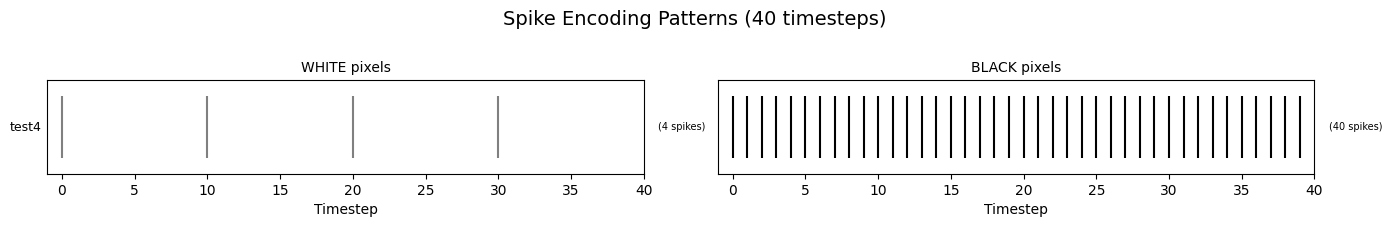

In [15]:
# Cell 4: Spike encoding visualization
fig, axes = plt.subplots(len(ENCODINGS), 2, figsize=(14, 2.2 * len(ENCODINGS)),
                         sharex=True, sharey=True, squeeze=False)
fig.suptitle("Spike Encoding Patterns (40 timesteps)", fontsize=14, y=1.01)

for row, (test_id, enc) in enumerate(ENCODINGS.items()):
    for col, (label, pattern) in enumerate([("WHITE", enc["white"]), ("BLACK", enc["black"])]):
        ax = axes[row, col]
        spike_times = [t for t, bit in enumerate(pattern) if bit == '1']
        if spike_times:
            ax.eventplot([spike_times], lineoffsets=0, linelengths=0.8,
                        colors='black' if label == "BLACK" else 'gray')
        ax.set_xlim(-1, 40)
        ax.set_ylim(-0.6, 0.6)
        ax.set_yticks([])
        if col == 0:
            ax.set_ylabel(test_id, fontsize=9, rotation=0, ha='right', va='center')
        if row == 0:
            ax.set_title(f"{label} pixels", fontsize=10)
        if row == len(ENCODINGS) - 1:
            ax.set_xlabel("Timestep")
        # Annotate with spike count
        ax.text(41, 0, f"({len(spike_times)} spikes)", fontsize=7, va='center')

fig.tight_layout()
plt.show()

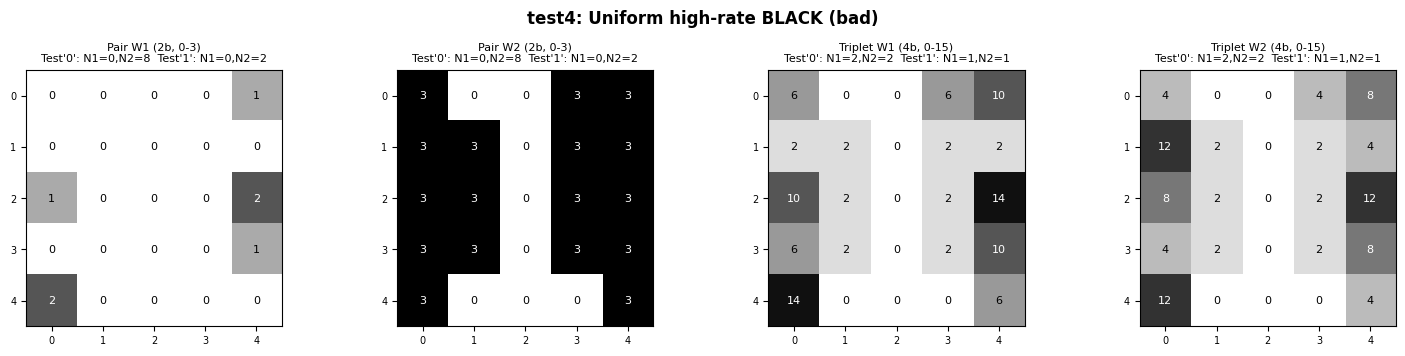

In [16]:
# Cell 5: Side-by-side weight heatmaps (main comparison)
# For each encoding: 1x4 grid [Pair W1 | Pair W2 | Triplet W1 | Triplet W2]
# Using AFTER weights from phase index 1 (after Train '1' = final trained weights)
# Note: pair uses 2-bit weights (0-3), triplet uses 4-bit weights (0-15)

for test_id, enc in ENCODINGS.items():
    fig, axes = plt.subplots(1, 4, figsize=(15, 3.5))
    fig.suptitle(f"{test_id}: {enc['name']}", fontsize=12, fontweight='bold')

    for i, (mode, wname) in enumerate([
        ("pair", "W1"), ("pair", "W2"), ("triplet", "W1"), ("triplet", "W2")
    ]):
        ax = axes[i]
        r = results[test_id][mode]
        vmax = 2**r["w_bits"] - 1
        # AFTER weights, phase index 1 = after Train '1'
        w = r["weights"][f"AFTER_{wname}"][1]

        ax.imshow(w, cmap='gray_r', vmin=0, vmax=vmax, interpolation='nearest')

        # Test firing counts (phases 2=Test'0', 3=Test'1')
        t0, t1 = r["firing"][2], r["firing"][3]
        mode_label = mode.capitalize()
        ax.set_title(f"{mode_label} {wname} ({r['w_bits']}b, 0-{vmax})\n"
                     f"Test'0': N1={t0[0]},N2={t0[1]}  Test'1': N1={t1[0]},N2={t1[1]}",
                     fontsize=8)
        ax.set_xticks(range(5))
        ax.set_yticks(range(5))
        ax.tick_params(labelsize=7)

        # Annotate cells with values
        for r_idx in range(5):
            for c_idx in range(5):
                val = w[r_idx, c_idx]
                color = 'black' if val < vmax / 2 else 'white'
                ax.text(c_idx, r_idx, str(val), ha='center', va='center',
                       fontsize=8, color=color)

    fig.tight_layout()
    plt.show()

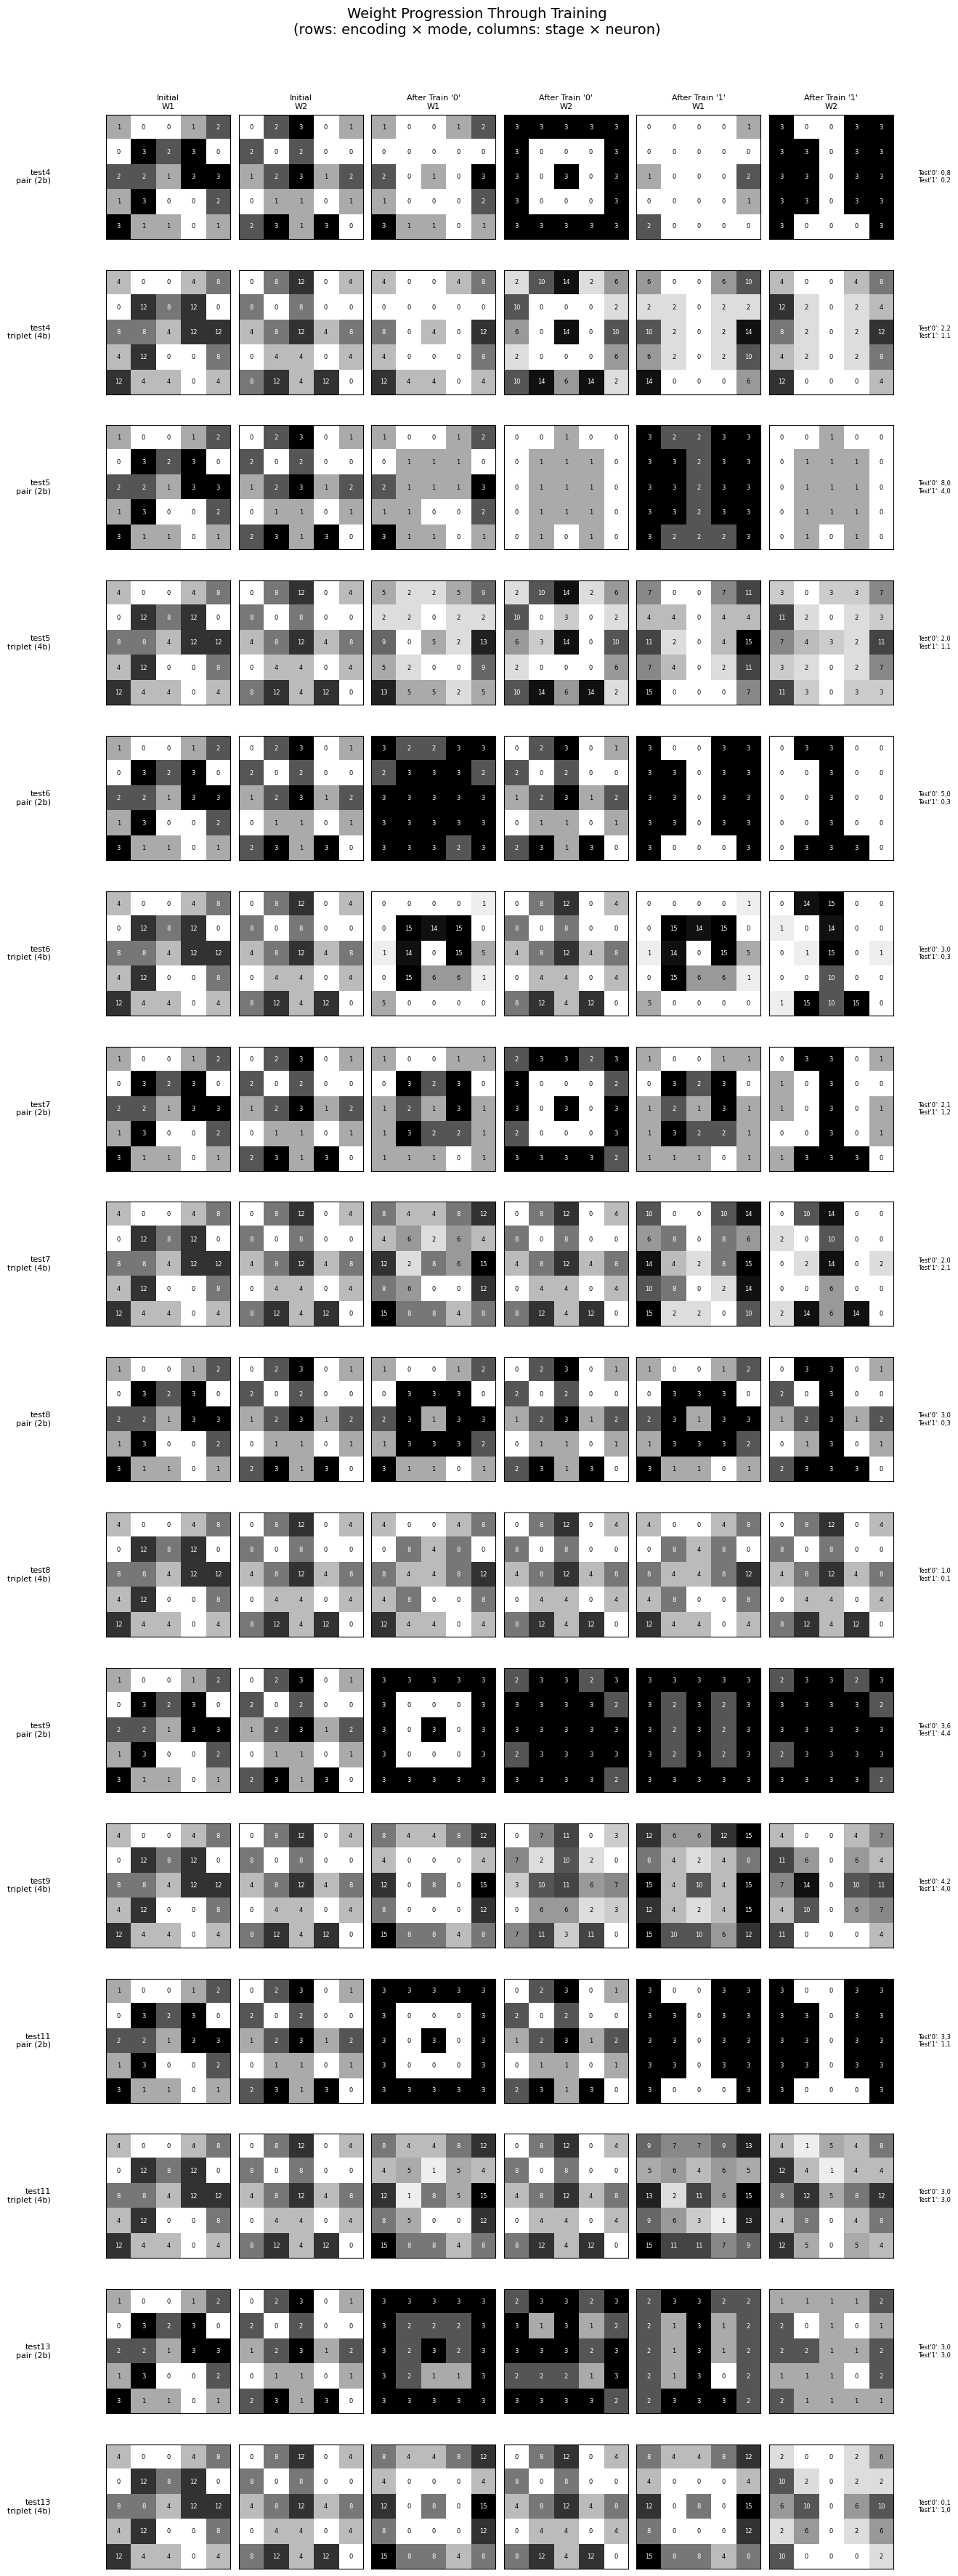

In [59]:
# Weight progression through training: Initial → After Train'0' → After Train'1'
# One big figure: rows = encoding × mode (pair/triplet), cols = stage × neuron (W1/W2)
# Note: pair (2-bit, 0-3) and triplet (4-bit, 0-15) have different weight ranges

stages = ["Initial", "After Train '0'", "After Train '1'"]
n_enc = len(ENCODINGS)
n_rows = n_enc * 2   # pair + triplet per encoding
n_cols = 6            # 3 stages × 2 neurons (W1, W2)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2.2, n_rows * 2.2))
fig.suptitle("Weight Progression Through Training\n(rows: encoding × mode, columns: stage × neuron)",
             fontsize=14, y=1.01)

for enc_idx, (test_id, enc) in enumerate(ENCODINGS.items()):
    for mode_idx, mode in enumerate(["pair", "triplet"]):
        row = enc_idx * 2 + mode_idx
        r = results[test_id][mode]
        vmax = 2**r["w_bits"] - 1

        for stage_idx, (stage_label, w1, w2) in enumerate([
            (stages[0], r["weights"]["BEFORE_W1"][0], r["weights"]["BEFORE_W2"][0]),
            (stages[1], r["weights"]["AFTER_W1"][0],  r["weights"]["AFTER_W2"][0]),
            (stages[2], r["weights"]["AFTER_W1"][1],  r["weights"]["AFTER_W2"][1]),
        ]):
            for neuron_idx, (wname, w) in enumerate([("W1", w1), ("W2", w2)]):
                col = stage_idx * 2 + neuron_idx
                ax = axes[row, col]

                ax.imshow(w, cmap='gray_r', vmin=0, vmax=vmax, interpolation='nearest')

                # Annotate cell values
                for ri in range(5):
                    for ci in range(5):
                        val = w[ri, ci]
                        color = 'black' if val < vmax / 2 else 'white'
                        ax.text(ci, ri, str(val), ha='center', va='center',
                               fontsize=6, color=color)

                ax.set_xticks([])
                ax.set_yticks([])

                # Column headers on top row
                if row == 0:
                    ax.set_title(f"{stage_label}\n{wname}", fontsize=8)

                # Row labels on left column
                if col == 0:
                    ax.set_ylabel(f"{test_id}\n{mode} ({r['w_bits']}b)", fontsize=8, rotation=0,
                                  ha='right', va='center', labelpad=55)

        # Add firing counts annotation on the rightmost column for this row
        t0, t1 = r["firing"][2], r["firing"][3]
        ax_right = axes[row, n_cols - 1]
        fire_text = f"Test'0': {t0[0]},{t0[1]}\nTest'1': {t1[0]},{t1[1]}"
        ax_right.text(5.5, 2, fire_text, fontsize=6, va='center', ha='left',
                     transform=ax_right.transData)

fig.tight_layout()
plt.show()